# EfficientTruthBOOSTING v2 -- Cross-Attention Fusion
**Multimodal Fake News Detection | Unified Fakeddit Dataset**

Architecture: Feature Extraction (Content + Context) --> Attention Fusion Layer --> Classification

**Runtime:** Set to T4 GPU before running (`Runtime > Change runtime type > T4 GPU`)


## 1. Setup and Imports


In [ ]:
!pip install -q tensorflow scikit-learn pandas matplotlib numpy requests Pillow tabulate

import tensorflow as tf
import numpy as np
import pandas as pd
import os, re, gc, io, pickle, requests
import matplotlib.pyplot as plt
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc, mean_squared_error, mean_absolute_error,
    precision_recall_fscore_support)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0
from scipy.stats import chi2_contingency, chisquare
from tabulate import tabulate

gpus = tf.config.list_physical_devices('GPU')
print(gpus)
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU detected: {len(gpus)} device(s)")
else:
    print("WARNING: No GPU found.")



[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU detected: 1 device(s)


## 2. Configuration


In [ ]:
# Architecture
D_MODEL = 128
NUM_HEADS = 3
FFN_DIM = 256
DROPOUT_RATE = 0.3
TFIDF_MAX = 2000
IMG_SIZE = 128

# Training
BATCH_SIZE = 256
EPOCHS = 50
LR = 0.001
SEED = 42

# Image processing
CHUNK_SIZE = 100000
DOWNLOAD_THREADS = 32
PRED_BATCH = 64

# Data quality
MIN_TEXT_LENGTH = 5

# Context columns
CONTEXT_COLS = ['hashtag_count', 'mentions_count', 'text_length', 'engagement_score']

# Paths
DRIVE_DIR = "/content/drive/MyDrive"
# For Kaggle: DRIVE_DIR = "/kaggle/working"
EMBEDDINGS_PATH = os.path.join(DRIVE_DIR, "image_embeddings_fakeddit.npy")
MODEL_SAVE_DIR = os.path.join(DRIVE_DIR, "truthboosting_v2_models")


## 3. Load Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = os.path.join(DRIVE_DIR, "final_combined_dataset.csv")

data = pd.read_csv(DATASET_PATH, low_memory=False)
print(f"Dataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print(f"\nLabel distribution:\n{data['label'].value_counts()}")
data.head()


Mounted at /content/drive
Dataset shape: (705857, 10)
Columns: ['id', 'text', 'url', 'image_url', 'hashtag_count', 'mentions_count', 'text_length', 'has_url', 'engagement_score', 'label']

Label distribution:
label
0    431194
1    274663
Name: count, dtype: int64


,id,text,url,image_url,hashtag_count,mentions_count,text_length,has_url,engagement_score,label
0,bi8vzu,the way these cars are parked in a pattern,NaN,https://external-preview.redd.it/iitCkJF3ABaYK...,0,0,42,0,9.0,1
1,5uvwp2,pleased woman grasping a gnarly looking skate ...,NaN,https://external-preview.redd.it/O86Ji4jKiQ2Bz...,0,0,50,0,9.0,1
2,c9hdapq,heeheeheeheeheehee,NaN,http://i.imgur.com/23NF6NY.jpg,0,0,18,0,15.0,0
3,82xv8f,this extra special cat,NaN,https://preview.redd.it/8735rxootjk01.jpg?widt...,0,0,22,0,41.0,1
4,e0invg7,available here,NaN,https://i.redd.it/uadvhwla3h311.jpg,0,0,14,0,1.0,0


## 4. Data Preprocessing


In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower().strip()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@[^\s]+|#[^\s]+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data['clean_text'] = data['text'].apply(clean_text)
data = data.dropna(subset=['label']).reset_index(drop=True)
data['label'] = data['label'].astype(int)

for col in CONTEXT_COLS:
    if col in data.columns:
        data[col] = data[col].fillna(0).astype(float)

before = len(data)
data = data[data['clean_text'].str.len() >= MIN_TEXT_LENGTH].reset_index(drop=True)
print(f"Removed {before - len(data):,} rows with text < {MIN_TEXT_LENGTH} chars")
print(f"After preprocessing: {data.shape}")
print(f"  Real (0): {(data['label']==0).sum()}, Fake (1): {(data['label']==1).sum()}")


Removed 10,950 rows with text < 5 chars
After preprocessing: (694907, 11)
  Real (0): 420333, Fake (1): 274574


## 5. Feature Extraction Module\n### 5.1 Text Features (TF-IDF)


In [ ]:
tfidf = TfidfVectorizer(max_features=TFIDF_MAX)
text_features = tfidf.fit_transform(data['clean_text'].astype(str)).toarray().astype(np.float32)
TEXT_DIM = text_features.shape[1]
print(f"Text features: {text_features.shape}")


Text features: (694907, 2000)


### 5.2 Image Features (EfficientNetV2B0 at 128x128)\nCached to Drive after first run.


In [ ]:
if os.path.exists(EMBEDDINGS_PATH):
    print("Loading cached image embeddings from Drive...")
    image_features = np.load(EMBEDDINGS_PATH)
    IMG_DIM = image_features.shape[1]
    print(f"Loaded: {image_features.shape}")
else:
    print(f"First run -- computing embeddings at {IMG_SIZE}x{IMG_SIZE}.")
    print("Will be saved to Drive for future reuse.\n")

    img_model = EfficientNetV2B0(
        weights='imagenet', include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg'
    )
    img_model.trainable = False
    IMG_DIM = img_model.output_shape[-1]

    def download_image(args):
        idx, url = args
        try:
            if not isinstance(url, str) or not url.startswith('http'):
                return idx, None
            resp = requests.get(url, timeout=5)
            if resp.status_code != 200:
                return idx, None
            img = Image.open(io.BytesIO(resp.content)).convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            return idx, np.array(img, dtype=np.float32) / 255.0
        except:
            return idx, None

    total = len(data)
    image_features = np.zeros((total, IMG_DIM), dtype=np.float32)
    total_success = 0
    total_chunks = (total + CHUNK_SIZE - 1) // CHUNK_SIZE

    for chunk_start in range(0, total, CHUNK_SIZE):
        chunk_end = min(chunk_start + CHUNK_SIZE, total)
        chunk_num = chunk_start // CHUNK_SIZE + 1
        print(f"\nChunk {chunk_num}/{total_chunks} [{chunk_start:,} to {chunk_end:,}]")
        urls = [(i, data.loc[i, 'image_url']) for i in range(chunk_start, chunk_end)]
        downloaded = {}
        with ThreadPoolExecutor(max_workers=DOWNLOAD_THREADS) as pool:
            futures = {pool.submit(download_image, u): u for u in urls}
            done = 0
            for f in as_completed(futures):
                idx, arr = f.result()
                if arr is not None:
                    downloaded[idx] = arr
                done += 1
                if done % 5000 == 0:
                    print(f"  Downloaded: {done:,}/{len(urls):,} ({len(downloaded):,} ok)")
        print(f"  Download complete: {len(downloaded):,}/{len(urls):,}")
        indices = sorted(downloaded.keys())
        for start in range(0, len(indices), PRED_BATCH):
            batch_idx = indices[start:start + PRED_BATCH]
            batch_imgs = np.stack([downloaded[i] for i in batch_idx])
            batch_emb = img_model.predict(batch_imgs, verbose=0)
            for j, idx in enumerate(batch_idx):
                image_features[idx] = batch_emb[j]
        total_success += len(downloaded)
        del downloaded; gc.collect()
        print(f"  Embedded. Total: {total_success:,}/{total:,}")

    np.save(EMBEDDINGS_PATH, image_features)
    print(f"\nSaved: {EMBEDDINGS_PATH}")
    del img_model; gc.collect()

print(f"Image features: {image_features.shape}")
valid = np.any(image_features != 0, axis=1).sum()
print(f"Valid embeddings: {valid:,}/{len(image_features):,} ({valid/len(image_features)*100:.1f}%)")


Loading cached image embeddings from Drive...
Loaded: (694907, 1280)
Image features: (694907, 1280)
Valid embeddings: 189,560/694,907 (27.3%)


### 5.3 Link/URL Features


In [ ]:
def extract_url_features(url):
    if not isinstance(url, str) or not url.startswith('http'):
        return np.zeros(8, dtype=np.float32)
    parts = url.split('/')
    domain = parts[2] if len(parts) > 2 else ''
    return np.array([
        len(url), url.count('/'), url.count('.'), url.count('-'),
        1.0 if 'https' in url else 0.0,
        1.0 if any(c.isdigit() for c in domain) else 0.0,
        1.0 if any(s in url for s in ['bit.ly','tinyurl','goo.gl','t.co']) else 0.0,
        float(len(domain)),
    ], dtype=np.float32)

url_col = 'url' if ('url' in data.columns and data['url'].notna().sum() > 100) else 'image_url'
link_features = np.array([extract_url_features(u) for u in data[url_col]], dtype=np.float32)
link_scaler = StandardScaler()
link_features = link_scaler.fit_transform(link_features).astype(np.float32)
LINK_DIM = link_features.shape[1]
print(f"Link features: {link_features.shape}")


Link features: (694907, 8)


### 5.4 Context Features (User Engagement)


In [ ]:
available_context = [c for c in CONTEXT_COLS if c in data.columns]
print(f"Context columns: {available_context}")
context_features = data[available_context].values.astype(np.float32)
context_scaler = StandardScaler()
context_features = context_scaler.fit_transform(context_features).astype(np.float32)
CONTEXT_DIM = context_features.shape[1]
print(f"Context features: {context_features.shape}")

labels = data['label'].values.astype(np.float32)


Context columns: ['hashtag_count', 'mentions_count', 'text_length', 'engagement_score']
Context features: (694907, 4)


## 6. Model Architecture


In [ ]:
class ModalityProjection(layers.Layer):
    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs)
        self.dense = layers.Dense(d_model, activation='relu')
        self.norm = layers.LayerNormalization()
        self.dropout = layers.Dropout(DROPOUT_RATE)
    def call(self, x, training=False):
        return self.dropout(self.norm(self.dense(x)), training=training)

class AttentionFusionLayer(layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.attention_heads = [
            layers.MultiHeadAttention(num_heads=1, key_dim=d_model, name=f'head_{i}')
            for i in range(num_heads)
        ]
        self.fused_norm = layers.LayerNormalization()
        self.fused_ffn = keras.Sequential([
            layers.Dense(FFN_DIM, activation='relu'),
            layers.Dropout(DROPOUT_RATE),
            layers.Dense(d_model * num_heads),
        ], name='fusion_ffn')
        self.output_norm = layers.LayerNormalization()
    def call(self, modality_features, training=False):
        stacked = tf.stack(modality_features, axis=1)
        head_outputs = []
        for head in self.attention_heads:
            attn = head(query=stacked, key=stacked, value=stacked, training=training)
            pooled = tf.reduce_mean(attn, axis=1)
            head_outputs.append(pooled)
        fused = self.fused_norm(tf.concat(head_outputs, axis=-1))
        refined = self.fused_ffn(fused, training=training)
        return self.output_norm(fused + refined)

class UserEngagementEmbedding(layers.Layer):
    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs)
        self.net = keras.Sequential([
            layers.Dense(64, activation='relu'),
            layers.LayerNormalization(),
            layers.Dense(d_model, activation='relu'),
            layers.Dropout(DROPOUT_RATE),
            layers.LayerNormalization(),
        ], name='ctx_embed')
    def call(self, x, training=False):
        return self.net(x, training=training)

def build_model():
    text_in = keras.Input(shape=(TEXT_DIM,), name='text_features')
    link_in = keras.Input(shape=(LINK_DIM,), name='link_features')
    image_in = keras.Input(shape=(IMG_DIM,), name='image_features')
    context_in = keras.Input(shape=(CONTEXT_DIM,), name='context_features')
    text_proj = ModalityProjection(D_MODEL, name='text_proj')(text_in)
    link_proj = ModalityProjection(D_MODEL, name='link_proj')(link_in)
    image_proj = ModalityProjection(D_MODEL, name='image_proj')(image_in)
    content_fused = AttentionFusionLayer(D_MODEL, NUM_HEADS, name='attention_fusion')(
        [text_proj, link_proj, image_proj])
    context_vec = UserEngagementEmbedding(D_MODEL, name='context_embed')(context_in)
    combined = layers.Concatenate(name='concat')([content_fused, context_vec])
    x = layers.Dense(256, activation='relu', name='fc_1')(combined)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(128, activation='relu', name='fc_2')(x)
    x = layers.Dropout(0.2)(x)
    output = layers.Dense(1, activation='sigmoid', name='output')(x)
    return keras.Model(inputs=[text_in, link_in, image_in, context_in],
                       outputs=output, name='EfficientTruthBOOSTING_v2')

print("Model architecture defined.")


Model architecture defined.


## 7. Helper Functions


In [ ]:
def make_split(text_f, link_f, image_f, ctx_f, lbls, train_r, test_r, val_r):
    temp_r = test_r + val_r
    t_tr, t_tmp, l_tr, l_tmp, i_tr, i_tmp, c_tr, c_tmp, y_tr, y_tmp = \
        train_test_split(text_f, link_f, image_f, ctx_f, lbls,
                         test_size=temp_r, random_state=SEED, stratify=lbls)
    val_frac = val_r / temp_r
    t_te, t_vl, l_te, l_vl, i_te, i_vl, c_te, c_vl, y_te, y_vl = \
        train_test_split(t_tmp, l_tmp, i_tmp, c_tmp, y_tmp,
                         test_size=val_frac, random_state=SEED, stratify=y_tmp)
    return (t_tr, l_tr, i_tr, c_tr, y_tr,
            t_te, l_te, i_te, c_te, y_te,
            t_vl, l_vl, i_vl, c_vl, y_vl)

def make_datasets(t_tr, l_tr, i_tr, c_tr, y_tr,
                  t_te, l_te, i_te, c_te, y_te,
                  t_vl, l_vl, i_vl, c_vl, y_vl):
    def to_ds(t, l, i, c, y, shuffle=False):
        ds = tf.data.Dataset.from_tensor_slices((
            {'text_features': t, 'link_features': l,
             'image_features': i, 'context_features': c}, y))
        if shuffle:
            ds = ds.shuffle(10000)
        return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return (to_ds(t_tr, l_tr, i_tr, c_tr, y_tr, shuffle=True),
            to_ds(t_te, l_te, i_te, c_te, y_te),
            to_ds(t_vl, l_vl, i_vl, c_vl, y_vl))

def train_new_model(train_ds, val_ds, split_name):
    model = build_model()
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')])
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=10, mode='max', restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6)]
    print(f"\nTraining [{split_name}]...")
    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=EPOCHS, callbacks=callbacks, verbose=1)
    return model, history

def compute_metrics(model, ds, y_true_arr, set_name):
    y_proba = model.predict(ds, verbose=0).flatten()
    y_pred = (y_proba >= 0.5).astype(int)
    y_true = y_true_arr.astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1_val = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc_val = roc_auc_score(y_true, y_proba)
    except ValueError:
        auc_val = 0.0
    mse = mean_squared_error(y_true, y_proba)
    mae = mean_absolute_error(y_true, y_proba)
    rmse = np.sqrt(mse)
    cm = confusion_matrix(y_true, y_pred)
    # Chi-Square test on confusion matrix
    cm2 = confusion_matrix(y_true, y_pred)
    if cm2.shape == (2, 2) and cm2.sum() > 0:
        chi2_stat, chi2_p, chi2_dof, chi2_expected = chi2_contingency(cm2)
    else:
        chi2_stat, chi2_p, chi2_dof = 0.0, 1.0, 0

    return {
        'set': set_name, 'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1_val, 'auc_roc': auc_val, 'mse': mse, 'mae': mae, 'rmse': rmse,
        'chi_square': chi2_stat, 'chi_square_p': chi2_p, 'chi_square_dof': chi2_dof,
        'confusion_matrix': cm, 'y_true': y_true, 'y_pred': y_pred, 'y_proba': y_proba,
    }

def save_model(model, history, split_tag):
    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
    kp = os.path.join(MODEL_SAVE_DIR, f"truthboosting_v2_{split_tag}.keras")
    model.save(kp)
    pkl = {
        'model_weights': model.get_weights(),
        'model_config': {'D_MODEL': D_MODEL, 'NUM_HEADS': NUM_HEADS, 'FFN_DIM': FFN_DIM,
                         'DROPOUT_RATE': DROPOUT_RATE, 'TEXT_DIM': TEXT_DIM, 'LINK_DIM': LINK_DIM,
                         'IMG_DIM': IMG_DIM, 'CONTEXT_DIM': CONTEXT_DIM},
        'tfidf_vectorizer': tfidf, 'link_scaler': link_scaler,
        'context_scaler': context_scaler, 'training_history': history.history,
    }
    pp = os.path.join(MODEL_SAVE_DIR, f"truthboosting_v2_{split_tag}.pkl")
    with open(pp, 'wb') as f:
        pickle.dump(pkl, f)
    print(f"Saved: {kp}")
    print(f"Saved: {pp}")
    return kp

def print_eval(metrics, split_name, set_type):
    print(f"\n{split_name} -- {set_type} Results:")
    for k in ['accuracy','precision','recall','f1','auc_roc','mse','mae','rmse']:
        print(f"  {k:12s}: {metrics[k]:.4f}")

print("Helper functions defined.")



Helper functions defined.


## 8. Experiment 1: Split 70:20:10 (Train:Test:Val)


In [ ]:
split_data_0 = make_split(
    text_features, link_features, image_features, context_features, labels,
    train_r=0.70, test_r=0.20, val_r=0.10)

t_tr_0, l_tr_0, i_tr_0, c_tr_0, y_tr_0 = split_data_0[0:5]
t_te_0, l_te_0, i_te_0, c_te_0, y_te_0 = split_data_0[5:10]
t_vl_0, l_vl_0, i_vl_0, c_vl_0, y_vl_0 = split_data_0[10:15]

print(f"Split 70:20:10")
print(f"  Train: {len(y_tr_0):,} | Test: {len(y_te_0):,} | Val: {len(y_vl_0):,}")

train_ds_0, test_ds_0, val_ds_0 = make_datasets(
    t_tr_0, l_tr_0, i_tr_0, c_tr_0, y_tr_0,
    t_te_0, l_te_0, i_te_0, c_te_0, y_te_0,
    t_vl_0, l_vl_0, i_vl_0, c_vl_0, y_vl_0)

pkl_path_0 = os.path.join(MODEL_SAVE_DIR, "truthboosting_v2_70_20_10.pkl")

if os.path.exists(pkl_path_0):
    print(f"Loading model from pickle: {pkl_path_0}")
    with open(pkl_path_0, 'rb') as f:
        pkl_data = pickle.load(f)
    model_0 = build_model()
    model_0.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')])
    model_0.set_weights(pkl_data['model_weights'])
    history_0 = type('obj', (object,), {'history': pkl_data.get('training_history', {})})()
    print("Model loaded successfully.")
else:
    print("No saved model found, training from scratch...")
    model_0, history_0 = train_new_model(train_ds_0, val_ds_0, "70:20:10")
    save_model(model_0, history_0, "70_20_10")

val_metrics_0 = compute_metrics(model_0, val_ds_0, y_vl_0, "Val (10%)")
test_metrics_0 = compute_metrics(model_0, test_ds_0, y_te_0, "Test (20%)")
print_eval(test_metrics_0, "70:20:10", "Test")
print_eval(val_metrics_0, "70:20:10", "Validation")
print(f"\n{classification_report(test_metrics_0['y_true'], test_metrics_0['y_pred'], target_names=['Real (0)', 'Fake (1)'])}")


Split 70:20:10
  Train: 486,434 | Test: 138,982 | Val: 69,491
Loading model from pickle: /content/drive/MyDrive/truthboosting_v2_models/truthboosting_v2_70_20_10.pkl
Model loaded successfully.

70:20:10 -- Test Results:
  accuracy    : 0.8425
  precision   : 0.8073
  recall      : 0.7900
  f1          : 0.7986
  auc_roc     : 0.9164
  mse         : 0.1129
  mae         : 0.2211
  rmse        : 0.3360

70:20:10 -- Validation Results:
  accuracy    : 0.8421
  precision   : 0.8086
  recall      : 0.7864
  f1          : 0.7973
  auc_roc     : 0.9158
  mse         : 0.1132
  mae         : 0.2211
  rmse        : 0.3365

              precision    recall  f1-score   support

    Real (0)       0.86      0.88      0.87     84067
    Fake (1)       0.81      0.79      0.80     54915

    accuracy                           0.84    138982
   macro avg       0.84      0.83      0.83    138982
weighted avg       0.84      0.84      0.84    138982



## 9. Experiment 2: Split 75:15:10 (Train:Test:Val)


In [ ]:
split_data_1 = make_split(
    text_features, link_features, image_features, context_features, labels,
    train_r=0.75, test_r=0.15, val_r=0.10)

t_tr_1, l_tr_1, i_tr_1, c_tr_1, y_tr_1 = split_data_1[0:5]
t_te_1, l_te_1, i_te_1, c_te_1, y_te_1 = split_data_1[5:10]
t_vl_1, l_vl_1, i_vl_1, c_vl_1, y_vl_1 = split_data_1[10:15]

print(f"Split 75:15:10")
print(f"  Train: {len(y_tr_1):,} | Test: {len(y_te_1):,} | Val: {len(y_vl_1):,}")

train_ds_1, test_ds_1, val_ds_1 = make_datasets(
    t_tr_1, l_tr_1, i_tr_1, c_tr_1, y_tr_1,
    t_te_1, l_te_1, i_te_1, c_te_1, y_te_1,
    t_vl_1, l_vl_1, i_vl_1, c_vl_1, y_vl_1)

pkl_path_1 = os.path.join(MODEL_SAVE_DIR, "truthboosting_v2_75_15_10.pkl")

if os.path.exists(pkl_path_1):
    print(f"Loading model from pickle: {pkl_path_1}")
    with open(pkl_path_1, 'rb') as f:
        pkl_data_1 = pickle.load(f)
    model_1 = build_model()
    model_1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')])
    model_1.set_weights(pkl_data_1['model_weights'])
    history_1 = type('obj', (object,), {'history': pkl_data_1.get('training_history', {})})()
    print("Model loaded successfully.")
else:
    print("No saved model found, training from scratch...")
    model_1, history_1 = train_new_model(train_ds_1, val_ds_1, "75:15:10")
    save_model(model_1, history_1, "75_15_10")

val_metrics_1 = compute_metrics(model_1, val_ds_1, y_vl_1, "Val (10%)")
test_metrics_1 = compute_metrics(model_1, test_ds_1, y_te_1, "Test (15%)")
print_eval(test_metrics_1, "75:15:10", "Test")
print_eval(val_metrics_1, "75:15:10", "Validation")
print(f"\n{classification_report(test_metrics_1['y_true'], test_metrics_1['y_pred'], target_names=['Real (0)', 'Fake (1)'])}")


Split 75:15:10
  Train: 521,180 | Test: 104,236 | Val: 69,491
Loading model from pickle: /content/drive/MyDrive/truthboosting_v2_models/truthboosting_v2_75_15_10.pkl
Model loaded successfully.

75:15:10 -- Test Results:
  accuracy    : 0.8443
  precision   : 0.8011
  recall      : 0.8060
  f1          : 0.8035
  auc_roc     : 0.9182
  mse         : 0.1119
  mae         : 0.2191
  rmse        : 0.3345

75:15:10 -- Validation Results:
  accuracy    : 0.8429
  precision   : 0.7986
  recall      : 0.8056
  f1          : 0.8021
  auc_roc     : 0.9165
  mse         : 0.1131
  mae         : 0.2204
  rmse        : 0.3362

              precision    recall  f1-score   support

    Real (0)       0.87      0.87      0.87     63050
    Fake (1)       0.80      0.81      0.80     41186

    accuracy                           0.84    104236
   macro avg       0.84      0.84      0.84    104236
weighted avg       0.84      0.84      0.84    104236



## 10. Experiment 3: Split 80:10:10 (Train:Test:Val)


In [ ]:
split_data_2 = make_split(
    text_features, link_features, image_features, context_features, labels,
    train_r=0.80, test_r=0.10, val_r=0.10)

t_tr_2, l_tr_2, i_tr_2, c_tr_2, y_tr_2 = split_data_2[0:5]
t_te_2, l_te_2, i_te_2, c_te_2, y_te_2 = split_data_2[5:10]
t_vl_2, l_vl_2, i_vl_2, c_vl_2, y_vl_2 = split_data_2[10:15]

print(f"Split 80:10:10")
print(f"  Train: {len(y_tr_2):,} | Test: {len(y_te_2):,} | Val: {len(y_vl_2):,}")

train_ds_2, test_ds_2, val_ds_2 = make_datasets(
    t_tr_2, l_tr_2, i_tr_2, c_tr_2, y_tr_2,
    t_te_2, l_te_2, i_te_2, c_te_2, y_te_2,
    t_vl_2, l_vl_2, i_vl_2, c_vl_2, y_vl_2)

pkl_path_2 = os.path.join(MODEL_SAVE_DIR, "truthboosting_v2_80_10_10.pkl")

if os.path.exists(pkl_path_2):
    print(f"Loading model from pickle: {pkl_path_2}")
    with open(pkl_path_2, 'rb') as f:
        pkl_data_2 = pickle.load(f)
    model_2 = build_model()
    model_2.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')])
    model_2.set_weights(pkl_data_2['model_weights'])
    history_2 = type('obj', (object,), {'history': pkl_data_2.get('training_history', {})})()
    print("Model loaded successfully.")
else:
    print("No saved model found, training from scratch...")
    model_2, history_2 = train_new_model(train_ds_2, val_ds_2, "80:10:10")
    save_model(model_2, history_2, "80_10_10")

val_metrics_2 = compute_metrics(model_2, val_ds_2, y_vl_2, "Val (10%)")
test_metrics_2 = compute_metrics(model_2, test_ds_2, y_te_2, "Test (10%)")
print_eval(test_metrics_2, "80:10:10", "Test")
print_eval(val_metrics_2, "80:10:10", "Validation")
print(f"\n{classification_report(test_metrics_2['y_true'], test_metrics_2['y_pred'], target_names=['Real (0)', 'Fake (1)'])}")


Split 80:10:10
  Train: 555,925 | Test: 69,491 | Val: 69,491
Loading model from pickle: /content/drive/MyDrive/truthboosting_v2_models/truthboosting_v2_80_10_10.pkl
Model loaded successfully.

80:10:10 -- Test Results:
  accuracy    : 0.8443
  precision   : 0.8128
  recall      : 0.7875
  f1          : 0.7999
  auc_roc     : 0.9179
  mse         : 0.1119
  mae         : 0.2319
  rmse        : 0.3345

80:10:10 -- Validation Results:
  accuracy    : 0.8436
  precision   : 0.8113
  recall      : 0.7875
  f1          : 0.7992
  auc_roc     : 0.9198
  mse         : 0.1108
  mae         : 0.2302
  rmse        : 0.3328

              precision    recall  f1-score   support

    Real (0)       0.86      0.88      0.87     42033
    Fake (1)       0.81      0.79      0.80     27458

    accuracy                           0.84     69491
   macro avg       0.84      0.83      0.84     69491
weighted avg       0.84      0.84      0.84     69491



## 11. Results Analysis and Discussion

Comprehensive comparison of all three split configurations.


In [ ]:
# TABLE 1: Test Set Metrics Comparison (All 3 Splits)
print("=" * 90)
print("TABLE 1: Test Set Performance Comparison")
print("=" * 90)

metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'mse', 'mae', 'rmse', 'chi_square', 'chi_square_p']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC', 'MSE', 'MAE', 'RMSE', 'Chi-Square', 'Chi-Square p-value']

headers = ["Metric", "70:20:10", "75:15:10", "80:10:10"]
rows = []
for label, key in zip(metric_labels, metric_keys):
    rows.append([label,
        f"{test_metrics_0[key]:.4f}",
        f"{test_metrics_1[key]:.4f}",
        f"{test_metrics_2[key]:.4f}"])
print(tabulate(rows, headers=headers, tablefmt="grid"))
print()



TABLE 1: Test Set Performance Comparison
+--------------------+------------+------------+------------+
| Metric             |   70:20:10 |   75:15:10 |   80:10:10 |
+====================+============+============+============+
| Accuracy           |     0.8425 |     0.8443 |     0.8443 |
+--------------------+------------+------------+------------+
| Precision          |     0.8073 |     0.8011 |     0.8128 |
+--------------------+------------+------------+------------+
| Recall             |     0.79   |     0.806  |     0.7875 |
+--------------------+------------+------------+------------+
| F1 Score           |     0.7986 |     0.8035 |     0.7999 |
+--------------------+------------+------------+------------+
| AUC-ROC            |     0.9164 |     0.9182 |     0.9179 |
+--------------------+------------+------------+------------+
| MSE                |     0.1129 |     0.1119 |     0.1119 |
+--------------------+------------+------------+------------+
| MAE                |     0.

In [ ]:
# TABLE 2: Validation Set Metrics Comparison (All 3 Splits)
print("=" * 90)
print("TABLE 2: Validation Set Performance Comparison")
print("=" * 90)

rows_val = []
for label, key in zip(metric_labels, metric_keys):
    rows_val.append([label,
        f"{val_metrics_0[key]:.4f}",
        f"{val_metrics_1[key]:.4f}",
        f"{val_metrics_2[key]:.4f}"])
print(tabulate(rows_val, headers=headers, tablefmt="grid"))
print()


TABLE 2: Validation Set Performance Comparison
+--------------------+------------+------------+------------+
| Metric             |   70:20:10 |   75:15:10 |   80:10:10 |
+====================+============+============+============+
| Accuracy           |     0.8421 |     0.8429 |     0.8436 |
+--------------------+------------+------------+------------+
| Precision          |     0.8086 |     0.7986 |     0.8113 |
+--------------------+------------+------------+------------+
| Recall             |     0.7864 |     0.8056 |     0.7875 |
+--------------------+------------+------------+------------+
| F1 Score           |     0.7973 |     0.8021 |     0.7992 |
+--------------------+------------+------------+------------+
| AUC-ROC            |     0.9158 |     0.9165 |     0.9198 |
+--------------------+------------+------------+------------+
| MSE                |     0.1132 |     0.1131 |     0.1108 |
+--------------------+------------+------------+------------+
| MAE                | 

In [ ]:
# TABLE 3: Dataset Split Sizes
print("=" * 90)
print("TABLE 3: Dataset Split Sizes")
print("=" * 90)

size_headers = ["Split Config", "Train", "Test", "Val", "Total"]
size_rows = [
    ["70:20:10", f"{len(y_tr_0):,}", f"{len(y_te_0):,}", f"{len(y_vl_0):,}",
     f"{len(y_tr_0)+len(y_te_0)+len(y_vl_0):,}"],
    ["75:15:10", f"{len(y_tr_1):,}", f"{len(y_te_1):,}", f"{len(y_vl_1):,}",
     f"{len(y_tr_1)+len(y_te_1)+len(y_vl_1):,}"],
    ["80:10:10", f"{len(y_tr_2):,}", f"{len(y_te_2):,}", f"{len(y_vl_2):,}",
     f"{len(y_tr_2)+len(y_te_2)+len(y_vl_2):,}"],
]
print(tabulate(size_rows, headers=size_headers, tablefmt="grid"))
print()


TABLE 3: Dataset Split Sizes
+----------------+---------+---------+--------+---------+
| Split Config   | Train   | Test    | Val    | Total   |
+================+=========+=========+========+=========+
| 70:20:10       | 486,434 | 138,982 | 69,491 | 694,907 |
+----------------+---------+---------+--------+---------+
| 75:15:10       | 521,180 | 104,236 | 69,491 | 694,907 |
+----------------+---------+---------+--------+---------+
| 80:10:10       | 555,925 | 69,491  | 69,491 | 694,907 |
+----------------+---------+---------+--------+---------+



In [ ]:
# TABLE 4: Per-Class Performance -- ALL Metrics for Real and Fake
print("=" * 110)
print("TABLE 4: Per-Class Performance on Test Set (All Metrics)")
print("=" * 110)

from sklearn.metrics import f1_score as f1_score_fn

def per_class_full_metrics(y_true, y_pred, y_proba, split_name):
    rows = []
    for cls_label, cls_name in [(0, "Real"), (1, "Fake")]:
        tp = ((y_pred == cls_label) & (y_true == cls_label)).sum()
        fp = ((y_pred == cls_label) & (y_true != cls_label)).sum()
        fn = ((y_pred != cls_label) & (y_true == cls_label)).sum()
        tn = ((y_pred != cls_label) & (y_true != cls_label)).sum()

        cls_acc = (tp + tn) / len(y_true) if len(y_true) > 0 else 0
        cls_prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        cls_rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        cls_f1 = 2 * cls_prec * cls_rec / (cls_prec + cls_rec) if (cls_prec + cls_rec) > 0 else 0

        # F1 Micro and Macro (computed globally, same for both classes)
        cls_f1_micro = f1_score_fn(y_true, y_pred, average='micro')
        cls_f1_macro = f1_score_fn(y_true, y_pred, average='macro')

        if cls_label == 1:
            cls_proba = y_proba
        else:
            cls_proba = 1 - y_proba

        cls_true_binary = (y_true == cls_label).astype(float)
        cls_mse = ((cls_true_binary - cls_proba) ** 2).mean()
        cls_mae = np.abs(cls_true_binary - cls_proba).mean()
        cls_rmse = np.sqrt(cls_mse)

        try:
            cls_auc = roc_auc_score(cls_true_binary, cls_proba)
        except:
            cls_auc = 0.0

        rows.append([
            f"{split_name} - {cls_name} ({cls_label})",
            f"{cls_acc:.4f}", f"{cls_prec:.4f}", f"{cls_rec:.4f}",
            f"{cls_f1:.4f}", f"{cls_f1_micro:.4f}", f"{cls_f1_macro:.4f}",
            f"{cls_auc:.4f}",
            f"{cls_mse:.4f}", f"{cls_mae:.4f}", f"{cls_rmse:.4f}",
            f"{tp+fn:,}"
        ])
    return rows

class_headers = ["Split / Class", "Accuracy", "Precision", "Recall", "F1",
                 "F1 Micro", "F1 Macro", "AUC-ROC", "MSE", "MAE", "RMSE", "Support"]

all_class_rows = []
for metrics, name in [
    (test_metrics_0, "70:20:10"),
    (test_metrics_1, "75:15:10"),
    (test_metrics_2, "80:10:10"),
]:
    all_class_rows += per_class_full_metrics(
        metrics['y_true'], metrics['y_pred'], metrics['y_proba'], name)
    all_class_rows.append([""] * 12)

print(tabulate(all_class_rows, headers=class_headers, tablefmt="grid"))
print()

# TABLE 5: Validation Set
print("=" * 110)
print("TABLE 5: Per-Class Performance on Validation Set (All Metrics)")
print("=" * 110)

all_val_class_rows = []
for metrics, name in [
    (val_metrics_0, "70:20:10"),
    (val_metrics_1, "75:15:10"),
    (val_metrics_2, "80:10:10"),
]:
    all_val_class_rows += per_class_full_metrics(
        metrics['y_true'], metrics['y_pred'], metrics['y_proba'], name)
    all_val_class_rows.append([""] * 12)

print(tabulate(all_val_class_rows, headers=class_headers, tablefmt="grid"))
print()


TABLE 4: Per-Class Performance on Test Set (All Metrics)
+---------------------+------------+-------------+----------+--------+------------+------------+-----------+--------+--------+--------+-----------+
| Split / Class       | Accuracy   | Precision   | Recall   | F1     | F1 Micro   | F1 Macro   | AUC-ROC   | MSE    | MAE    | RMSE   | Support   |
+=====================+============+=============+==========+========+============+============+===========+========+========+========+===========+
| 70:20:10 - Real (0) | 0.8425     | 0.8647      | 0.8768   | 0.8707 | 0.8425     | 0.8347     | 0.9164    | 0.1129 | 0.2211 | 0.3360 | 84,067    |
+---------------------+------------+-------------+----------+--------+------------+------------+-----------+--------+--------+--------+-----------+
| 70:20:10 - Fake (1) | 0.8425     | 0.8073      | 0.7900   | 0.7986 | 0.8425     | 0.8347     | 0.9164    | 0.1129 | 0.2211 | 0.3360 | 54,915    |
+---------------------+------------+-------------+-----

## 12. Chi-Square Test Analysis

Chi-Square test of independence on the confusion matrix evaluates whether the model's predictions are statistically significantly associated with the true labels.
A high Chi-Square statistic and low p-value (< 0.05) indicate the model's predictions are significantly better than random.


In [ ]:
# Chi-Square Test Results for All Splits
print("=" * 90)
print("Chi-Square Test of Independence on Confusion Matrix")
print("=" * 90)

chi_headers = ["Split", "Set", "Chi-Square Statistic", "p-value", "DOF", "Significant (p<0.05)"]
chi_rows = []

for split_name, t_metrics, v_metrics in [
    ("70:20:10", test_metrics_0, val_metrics_0),
    ("75:15:10", test_metrics_1, val_metrics_1),
    ("80:10:10", test_metrics_2, val_metrics_2),
]:
    for metrics, set_label in [(t_metrics, "Test"), (v_metrics, "Val")]:
        sig = "Yes" if metrics['chi_square_p'] < 0.05 else "No"
        chi_rows.append([
            split_name, set_label,
            f"{metrics['chi_square']:.4f}",
            f"{metrics['chi_square_p']:.2e}",
            f"{metrics['chi_square_dof']}",
            sig
        ])
    chi_rows.append(["", "", "", "", "", ""])

print(tabulate(chi_rows, headers=chi_headers, tablefmt="grid"))
print()

# Interpretation
print("Interpretation:")
print("- Chi-Square statistic measures how much observed predictions deviate from expected")
print("  (if predictions were independent of true labels).")
print("- A very small p-value (<<0.05) confirms the model's predictions are")
print("  significantly associated with real labels, i.e., the model is working.")
print("- Higher Chi-Square = stronger association between predictions and true labels.")


Chi-Square Test of Independence on Confusion Matrix
+----------+-------+------------------------+-----------+-------+------------------------+
| Split    | Set   | Chi-Square Statistic   | p-value   | DOF   | Significant (p<0.05)   |
+==========+=======+========================+===========+=======+========================+
| 70:20:10 | Test  | 62283.5996             | 0.00e+00  | 1     | Yes                    |
+----------+-------+------------------------+-----------+-------+------------------------+
| 70:20:10 | Val   | 31020.6123             | 0.00e+00  | 1     | Yes                    |
+----------+-------+------------------------+-----------+-------+------------------------+
|          |       |                        |           |       |                        |
+----------+-------+------------------------+-----------+-------+------------------------+
| 75:15:10 | Test  | 47424.4576             | 0.00e+00  | 1     | Yes                    |
+----------+-------+------------------

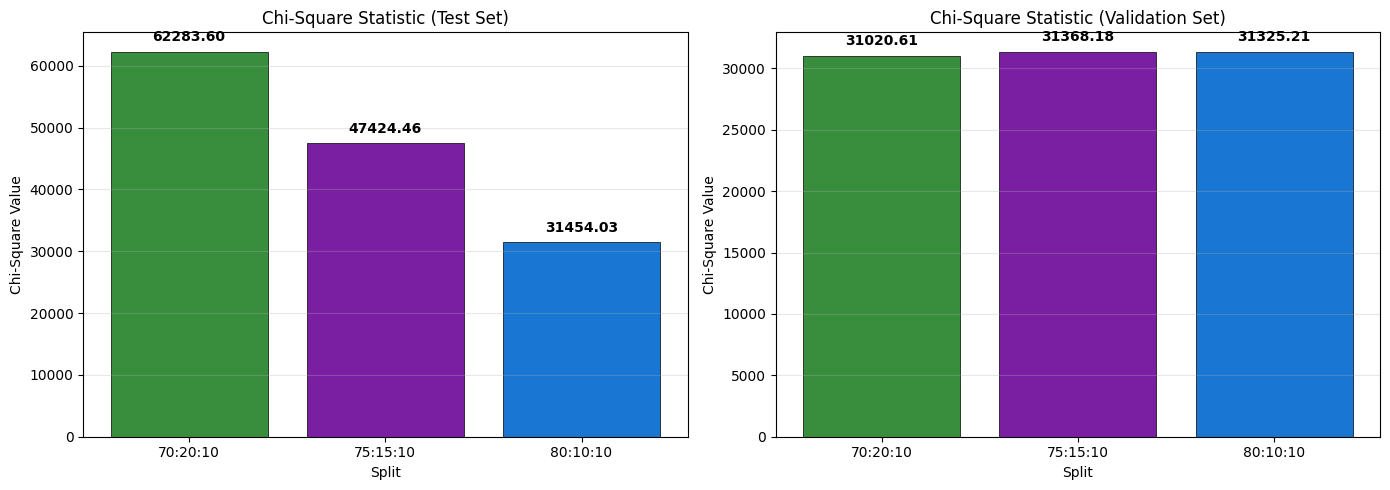

Chi-Square comparison saved.


In [ ]:
# Chi-Square Statistic Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

splits = ['70:20:10', '75:15:10', '80:10:10']
colors = ['#388E3C', '#7B1FA2', '#1976D2']

# Test set chi-square
test_chi = [test_metrics_0['chi_square'], test_metrics_1['chi_square'], test_metrics_2['chi_square']]
bars = axes[0].bar(splits, test_chi, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set(title='Chi-Square Statistic (Test Set)', ylabel='Chi-Square Value', xlabel='Split')
for bar, val in zip(bars, test_chi):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(test_chi)*0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Validation set chi-square
val_chi = [val_metrics_0['chi_square'], val_metrics_1['chi_square'], val_metrics_2['chi_square']]
bars = axes[1].bar(splits, val_chi, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set(title='Chi-Square Statistic (Validation Set)', ylabel='Chi-Square Value', xlabel='Split')
for bar, val in zip(bars, val_chi):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(val_chi)*0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "chi_square_comparison.png"), dpi=150)
plt.show()
print("Chi-Square comparison saved.")


## 13. Confusion Matrices



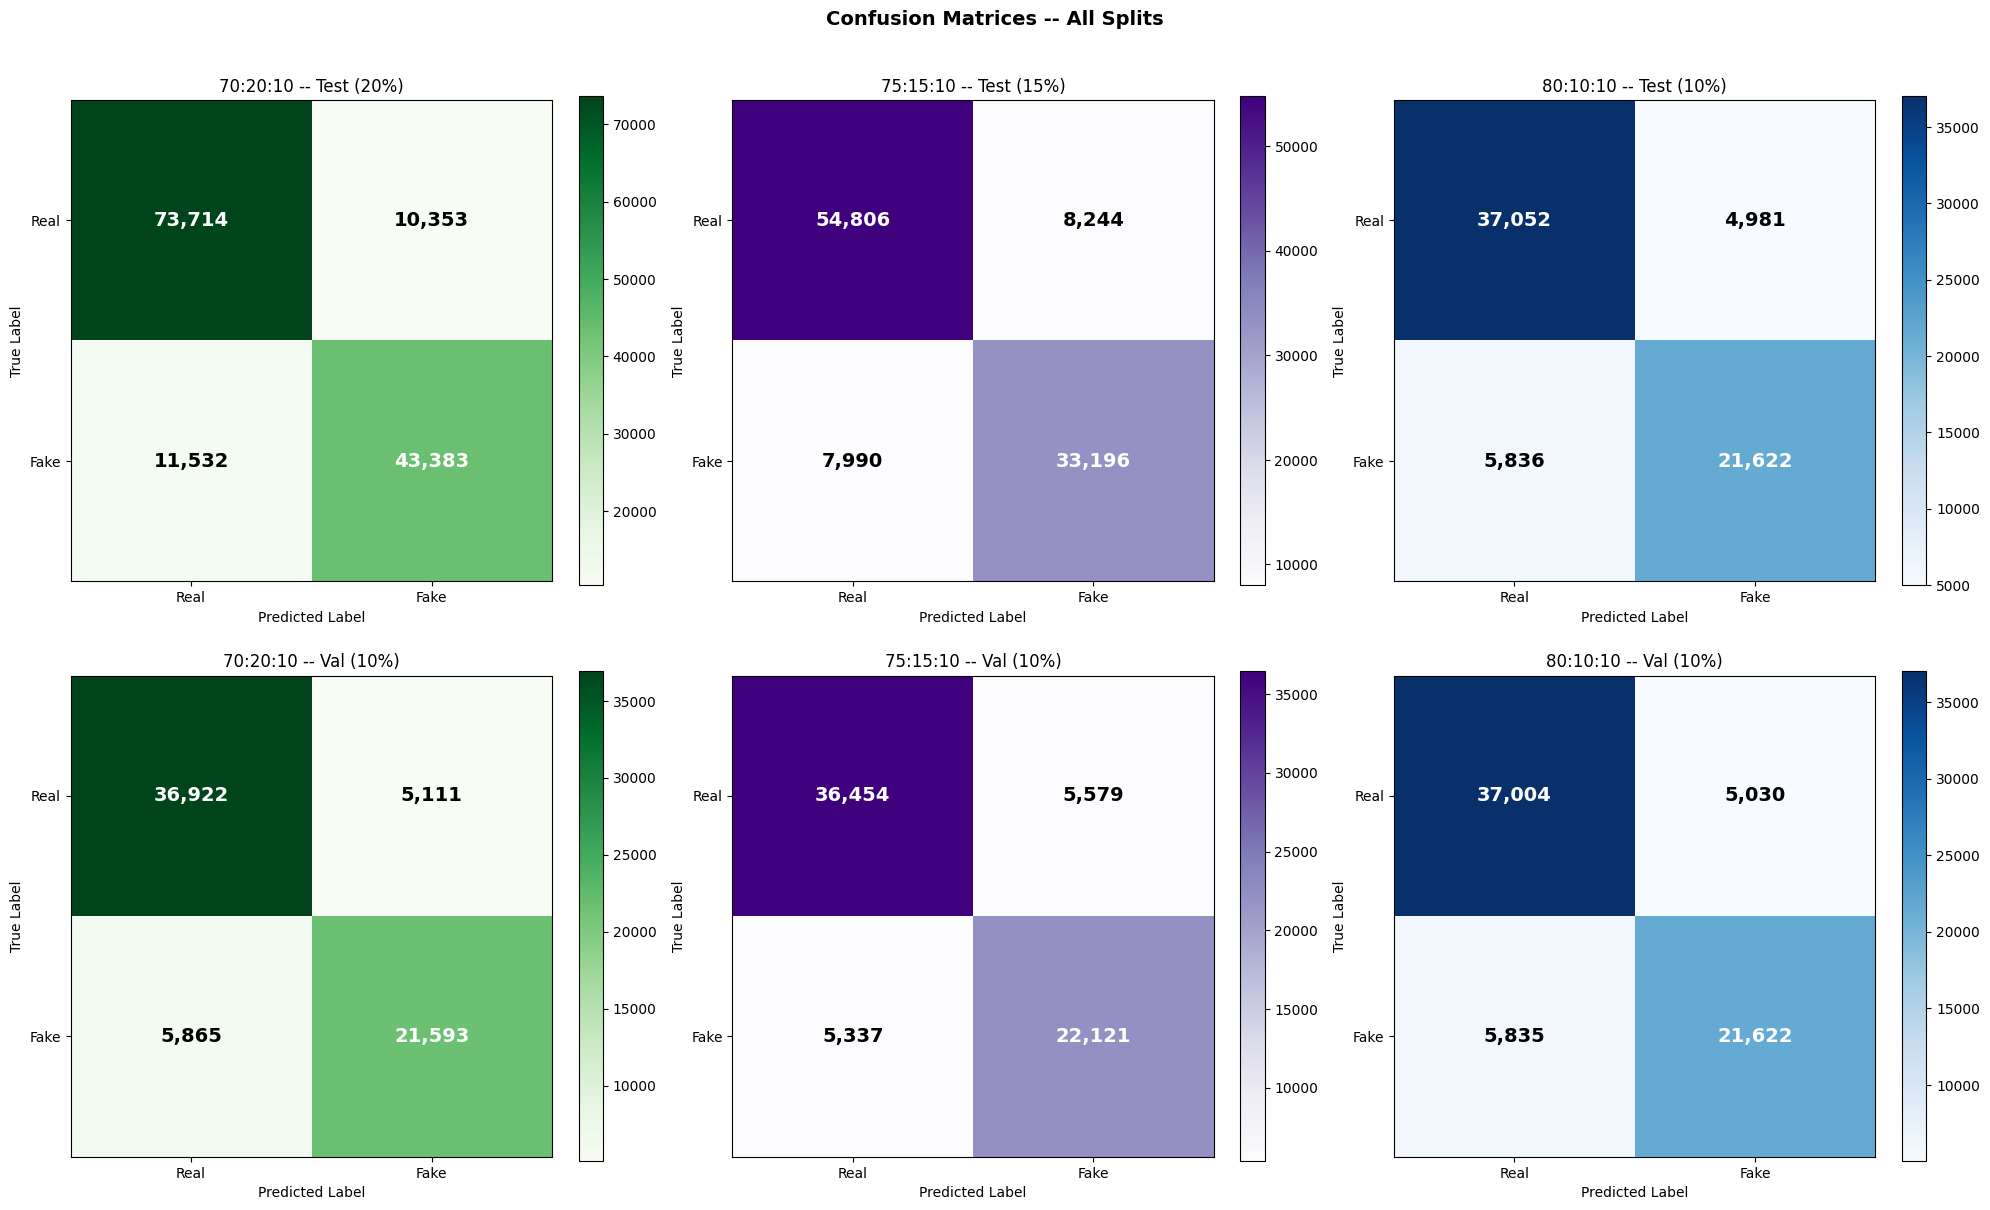

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

configs = [
    (test_metrics_0['confusion_matrix'], "70:20:10 -- Test (20%)", axes[0, 0], 'Greens'),
    (test_metrics_1['confusion_matrix'], "75:15:10 -- Test (15%)", axes[0, 1], 'Purples'),
    (test_metrics_2['confusion_matrix'], "80:10:10 -- Test (10%)", axes[0, 2], 'Blues'),
    (val_metrics_0['confusion_matrix'],  "70:20:10 -- Val (10%)",  axes[1, 0], 'Greens'),
    (val_metrics_1['confusion_matrix'],  "75:15:10 -- Val (10%)",  axes[1, 1], 'Purples'),
    (val_metrics_2['confusion_matrix'],  "80:10:10 -- Val (10%)",  axes[1, 2], 'Blues'),
]

for cm, title, ax, cmap in configs:
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax, fraction=0.046)
    ax.set(xticks=[0,1], yticks=[0,1], xticklabels=['Real','Fake'], yticklabels=['Real','Fake'],
           title=title, ylabel='True Label', xlabel='Predicted Label')
    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i,j], ',d'), ha='center', va='center',
                    color='white' if cm[i,j] > thresh else 'black', fontsize=14, fontweight='bold')

plt.suptitle('Confusion Matrices -- All Splits', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "confusion_matrices_all.png"), dpi=150, bbox_inches='tight')
plt.show()


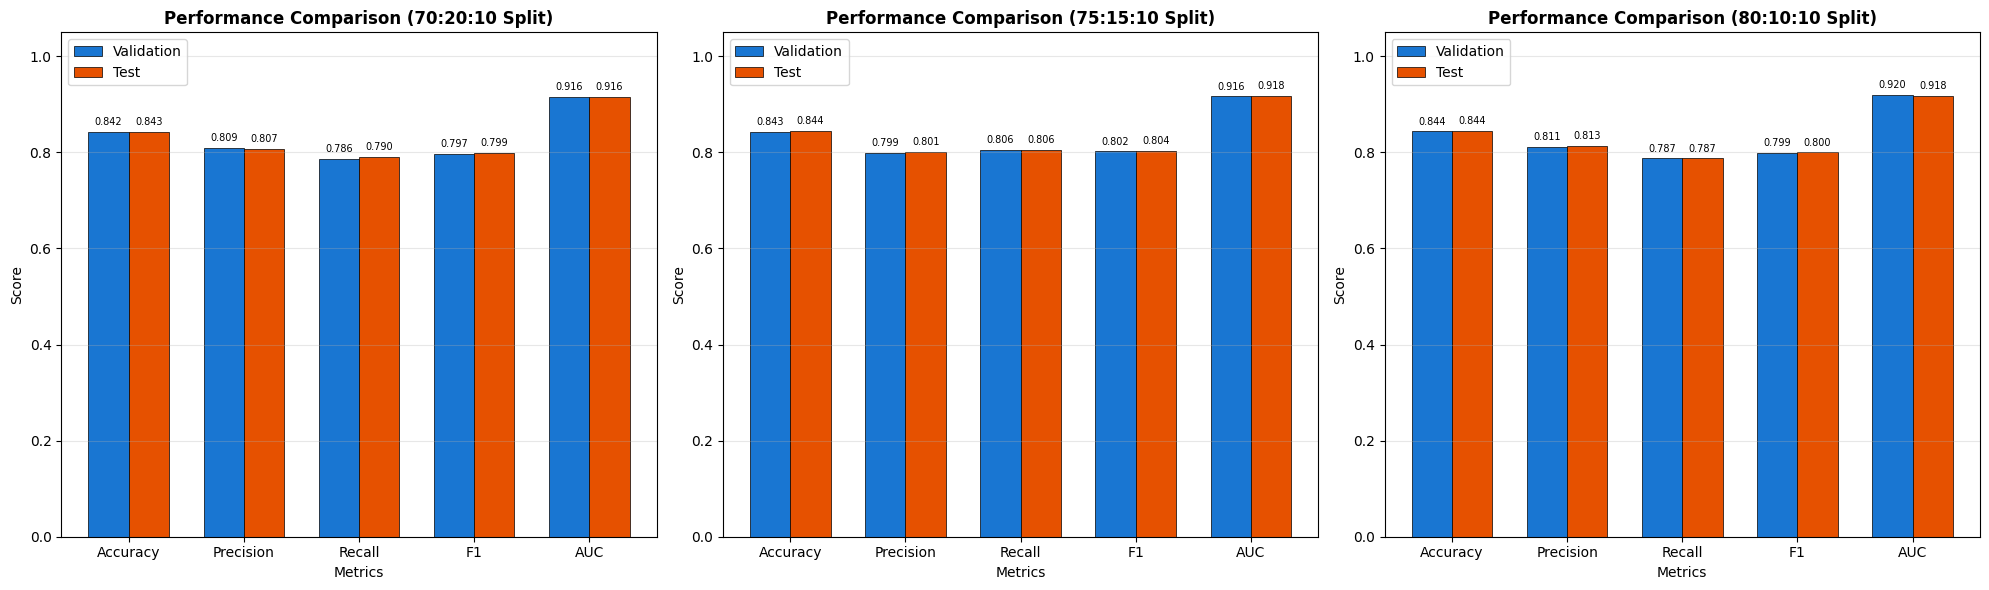

Saved: performance_comparison_all_splits.png


In [ ]:
# Performance Comparison Bar Charts for all 3 splits
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

splits = [
    ("70:20:10", val_metrics_0, test_metrics_0),
    ("75:15:10", val_metrics_1, test_metrics_1),
    ("80:10:10", val_metrics_2, test_metrics_2),
]

for idx, (split_name, val_m, test_m) in enumerate(splits):
    ax = axes[idx]
    val_vals = [val_m[k] for k in metrics_to_plot]
    test_vals = [test_m[k] for k in metrics_to_plot]

    x = np.arange(len(metric_names))
    width = 0.35

    bars1 = ax.bar(x - width/2, val_vals, width, label='Validation', color='#1976D2', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, test_vals, width, label='Test', color='#E65100', edgecolor='black', linewidth=0.5)

    ax.set_title(f'Performance Comparison ({split_name} Split)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "performance_comparison_all_splits.png"), dpi=150)
plt.show()
print("Saved: performance_comparison_all_splits.png")

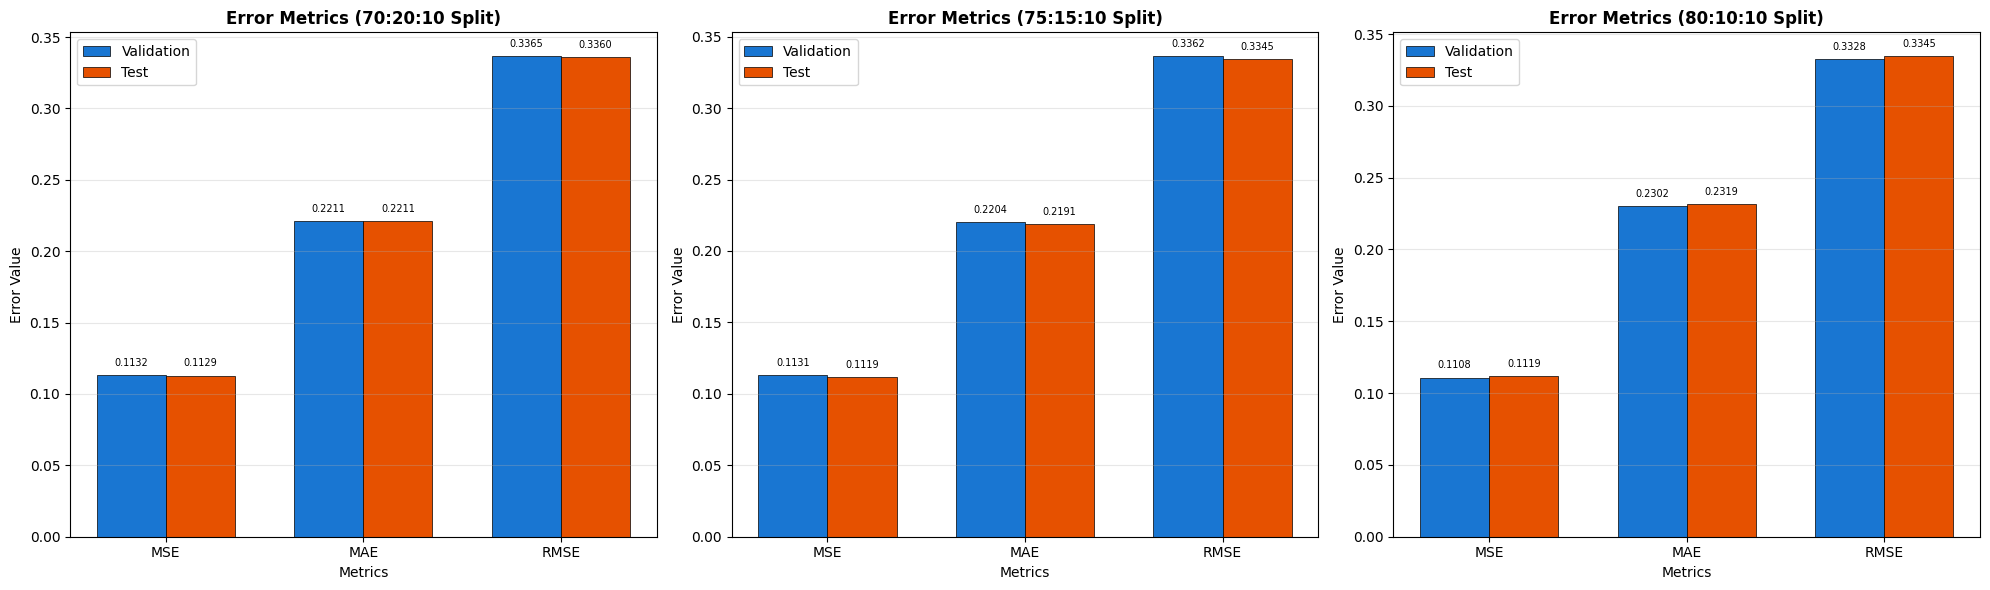

Saved: error_metrics_all_splits.png


In [ ]:
# Error Metrics Comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

error_keys = ['mse', 'mae', 'rmse']
error_names = ['MSE', 'MAE', 'RMSE']

for idx, (split_name, val_m, test_m) in enumerate(splits):
    ax = axes[idx]
    val_vals = [val_m[k] for k in error_keys]
    test_vals = [test_m[k] for k in error_keys]

    x = np.arange(len(error_names))
    width = 0.35

    bars1 = ax.bar(x - width/2, val_vals, width, label='Validation', color='#1976D2', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, test_vals, width, label='Test', color='#E65100', edgecolor='black', linewidth=0.5)

    ax.set_title(f'Error Metrics ({split_name} Split)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Error Value')
    ax.set_xticks(x)
    ax.set_xticklabels(error_names)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "error_metrics_all_splits.png"), dpi=150)
plt.show()
print("Saved: error_metrics_all_splits.png")

#F1 Scores and F1 Variaents F1 Macro and F1 Micro

In [ ]:
# Compute F1, F1-Micro, F1-Macro for all splits
from sklearn.metrics import f1_score

def add_f1_variants(metrics_dict):
    y_true = metrics_dict['y_true']
    y_pred = metrics_dict['y_pred']
    metrics_dict['f1_micro'] = f1_score(y_true, y_pred, average='micro')
    metrics_dict['f1_macro'] = f1_score(y_true, y_pred, average='macro')
    # f1 (weighted/binary) already exists as 'f1'
    return metrics_dict

# Add to all metrics
for m in [test_metrics_0, val_metrics_0, test_metrics_1, val_metrics_1, test_metrics_2, val_metrics_2]:
    add_f1_variants(m)

# Print F1 comparison table
f1_headers = ["Split", "Set", "F1 (Binary)", "F1 Micro", "F1 Macro"]
f1_rows = []
for split_name, test_m, val_m in [
    ("70:20:10", test_metrics_0, val_metrics_0),
    ("75:15:10", test_metrics_1, val_metrics_1),
    ("80:10:10", test_metrics_2, val_metrics_2),
]:
    f1_rows.append([split_name, "Test",
        f"{test_m['f1']:.4f}", f"{test_m['f1_micro']:.4f}", f"{test_m['f1_macro']:.4f}"])
    f1_rows.append([split_name, "Val",
        f"{val_m['f1']:.4f}", f"{val_m['f1_micro']:.4f}", f"{val_m['f1_macro']:.4f}"])
    f1_rows.append(["", "", "", "", ""])

print("=" * 70)
print("F1 Score Variants Comparison")
print("=" * 70)
print(tabulate(f1_rows, headers=f1_headers, tablefmt="grid"))


F1 Score Variants Comparison
+----------+-------+---------------+------------+------------+
| Split    | Set   | F1 (Binary)   | F1 Micro   | F1 Macro   |
+==========+=======+===============+============+============+
| 70:20:10 | Test  | 0.7986        | 0.8425     | 0.8347     |
+----------+-------+---------------+------------+------------+
| 70:20:10 | Val   | 0.7973        | 0.8421     | 0.8340     |
+----------+-------+---------------+------------+------------+
|          |       |               |            |            |
+----------+-------+---------------+------------+------------+
| 75:15:10 | Test  | 0.8035        | 0.8443     | 0.8373     |
+----------+-------+---------------+------------+------------+
| 75:15:10 | Val   | 0.8021        | 0.8429     | 0.8359     |
+----------+-------+---------------+------------+------------+
|          |       |               |            |            |
+----------+-------+---------------+------------+------------+
| 80:10:10 | Test  | 0.799

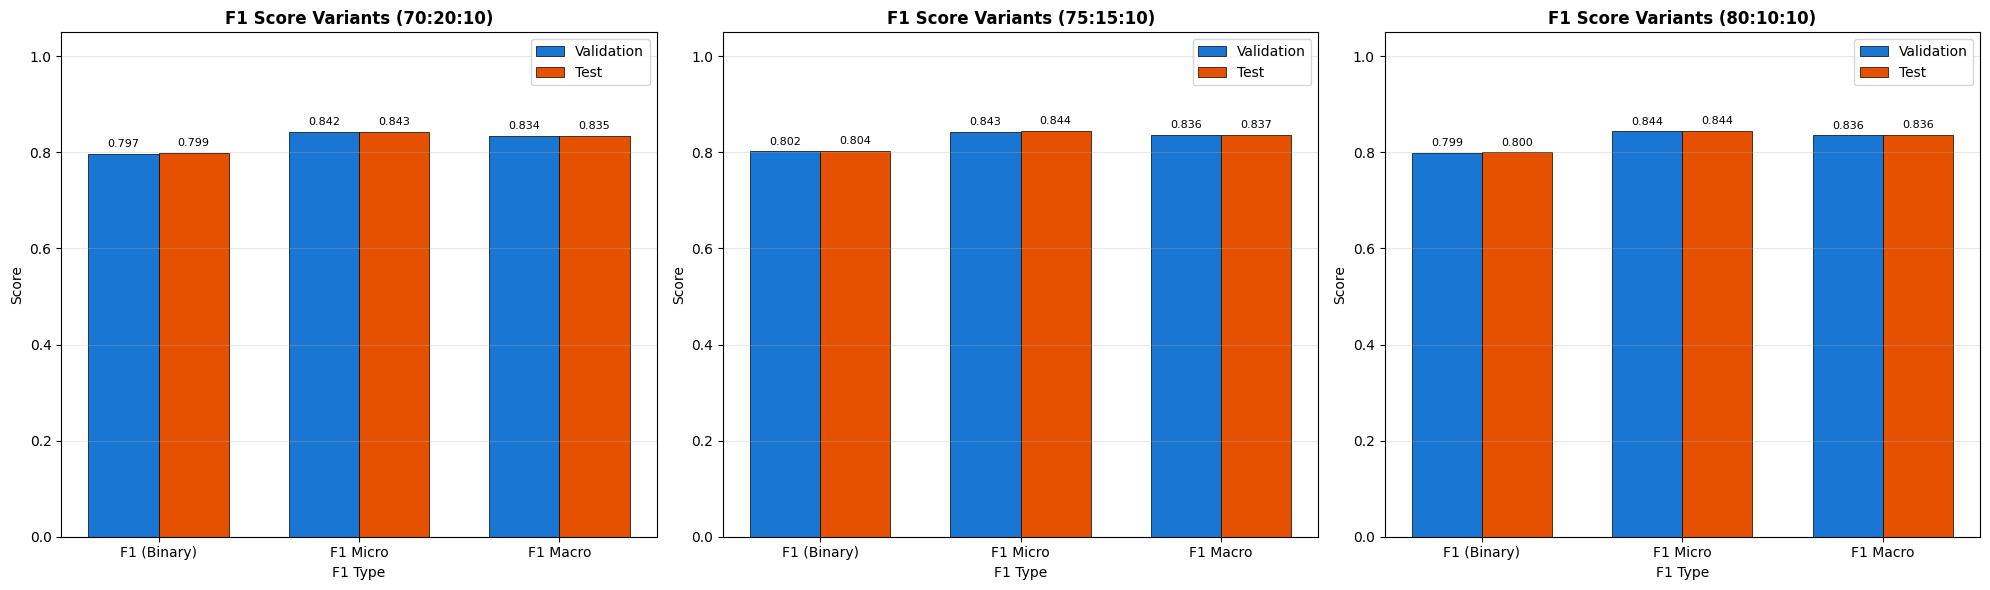

Saved: f1_variants_comparison.png


In [ ]:
# F1 Variants Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

f1_keys = ['f1', 'f1_micro', 'f1_macro']
f1_names = ['F1 (Binary)', 'F1 Micro', 'F1 Macro']

splits = [
    ("70:20:10", val_metrics_0, test_metrics_0),
    ("75:15:10", val_metrics_1, test_metrics_1),
    ("80:10:10", val_metrics_2, test_metrics_2),
]

for idx, (split_name, val_m, test_m) in enumerate(splits):
    ax = axes[idx]
    val_vals = [val_m[k] for k in f1_keys]
    test_vals = [test_m[k] for k in f1_keys]

    x = np.arange(len(f1_names))
    width = 0.35

    bars1 = ax.bar(x - width/2, val_vals, width, label='Validation', color='#1976D2', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, test_vals, width, label='Test', color='#E65100', edgecolor='black', linewidth=0.5)

    ax.set_title(f'F1 Score Variants ({split_name})', fontsize=12, fontweight='bold')
    ax.set_xlabel('F1 Type')
    ax.set_ylabel('Score')
    ax.set_xticks(x)
    ax.set_xticklabels(f1_names)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "f1_variants_comparison.png"), dpi=150)
plt.show()
print("Saved: f1_variants_comparison.png")


## 14. ROC Curves Comparison



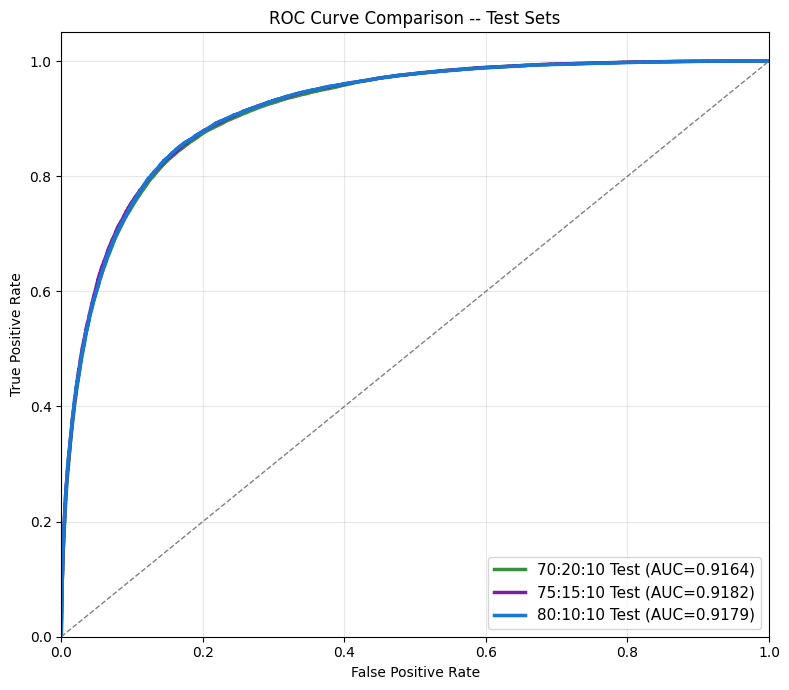

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

for metrics, label, color in [
    (test_metrics_0, "70:20:10 Test", '#388E3C'),
    (test_metrics_1, "75:15:10 Test", '#7B1FA2'),
    (test_metrics_2, "80:10:10 Test", '#1976D2'),
]:
    fpr, tpr, _ = roc_curve(metrics['y_true'], metrics['y_proba'])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{label} (AUC={roc_auc_val:.4f})')

ax.plot([0,1],[0,1], color='grey', linestyle='--', linewidth=1)
ax.set(xlim=[0,1], ylim=[0,1.05], xlabel='False Positive Rate',
       ylabel='True Positive Rate', title='ROC Curve Comparison -- Test Sets')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "roc_comparison_all.png"), dpi=150)
plt.show()


## 15. Training History Comparison



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for history, label, color in [
    (history_0, "70:20:10", '#388E3C'),
    (history_1, "75:15:10", '#7B1FA2'),
    (history_2, "80:10:10", '#1976D2'),
]:
    axes[0].plot(history.history['accuracy'], label=f'{label} Train', linewidth=2, color=color)
    axes[0].plot(history.history['val_accuracy'], label=f'{label} Val', linewidth=2, linestyle='--', color=color, alpha=0.7)
    axes[1].plot(history.history['loss'], label=f'{label} Train', linewidth=2, color=color)
    axes[1].plot(history.history['val_loss'], label=f'{label} Val', linewidth=2, linestyle='--', color=color, alpha=0.7)

axes[0].set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy Comparison')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set(xlabel='Epoch', ylabel='Loss', title='Loss Comparison')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "training_history_all.png"), dpi=150)
plt.show()


## 16. Final Summary Table



In [ ]:
print("=" * 100)
print("FINAL RESULTS SUMMARY -- EfficientTruthBOOSTING v2")
print("=" * 100)

summary_headers = ["Metric",
    "70:20:10 (Test)", "70:20:10 (Val)",
    "75:15:10 (Test)", "75:15:10 (Val)",
    "80:10:10 (Test)", "80:10:10 (Val)"]

summary_rows = []
for label, key in zip(metric_labels, metric_keys):
    summary_rows.append([label,
        f"{test_metrics_0[key]:.4f}", f"{val_metrics_0[key]:.4f}",
        f"{test_metrics_1[key]:.4f}", f"{val_metrics_1[key]:.4f}",
        f"{test_metrics_2[key]:.4f}", f"{val_metrics_2[key]:.4f}",
    ])
print(tabulate(summary_rows, headers=summary_headers, tablefmt="grid"))
print()

# Determine best split by F1
f1_scores = {
    "70:20:10": test_metrics_0['f1'],
    "75:15:10": test_metrics_1['f1'],
    "80:10:10": test_metrics_2['f1'],
}
best_split = max(f1_scores, key=f1_scores.get)
print(f"Best performing split (by F1 on Test): {best_split} (F1 = {f1_scores[best_split]:.4f})")

# Save as CSV
summary_df = pd.DataFrame(summary_rows, columns=summary_headers)
csv_path = os.path.join(MODEL_SAVE_DIR, "results_comparison_all.csv")
summary_df.to_csv(csv_path, index=False)
print(f"Results saved to: {csv_path}")


## Summary

| Split | Train | Test | Val | Models Saved |
|---|---|---|---|---|
| 70:20:10 | 70% | 20% | 10% | truthboosting_v2_70_20_10.keras / .pkl |
| 75:15:10 | 75% | 15% | 10% | truthboosting_v2_75_15_10.keras / .pkl |
| 80:10:10 | 80% | 10% | 10% | truthboosting_v2_80_10_10.keras / .pkl |

**Metrics:** Accuracy, Precision, Recall, F1, AUC-ROC, MSE, MAE, RMSE

**Visualizations:** 6 Confusion matrices, ROC curves overlay (3 splits), Training history comparison
